In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.cm as cm
from itertools import product

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

from vectorized_STFCM import vectorized_st_kmeans_

### Fonctions de générations des données simulées

In [2]:
# Death space function
def generate_death(
        peak_position: list[int],# Position approximative du maximum
        scale: list[int], # Echelle de la gaussienne
        max_observation: list[int], # Valeur maximale de l'observation
        n_clusters: int, # Nombre de clusters 
        n_simulations: list[int], # Nombre de simulations par clusters
        T: int = 20, # Nombre de pas de temps
        n_individuals = 101, # Nombre d'individus
):
    n_clusters = len(peak_position)
    individuals = np.arange(n_individuals)

    death_matrix = [np.zeros((n_simulations[i], T, n_individuals)) for i in range(n_clusters)]

    for c in range(n_clusters):
        for i in range(n_simulations[c]):
            for j in range(T):
                # Générer les observations basées sur une courbe gaussienne
                observation = (max_observation[c] + 5 * j) * np.exp(-0.5 * ((individuals - (peak_position[c]+j/8)) / (scale[c]-j/6))**2)

                # Ajouter du bruit aléatoire limité
                noise = np.random.uniform(50, 200, size=n_individuals)
                observation += noise
                observation = observation / np.sum(observation)
                plt.plot(individuals, observation, label='Simulated observations (no zeros)')
                death_matrix[c][i,j,:] = observation


    # Placer les données dans un format adapté pour le clustering
    death_matrix_new = death_matrix[0]
    for i in range(1, n_clusters):
        death_matrix_new = np.concatenate([death_matrix_new, death_matrix[i]], axis=0)

    return death_matrix_new



# Covariate space functions
def mapping_observ_clusters(n, c, n_per_cluster=None):
    """
    Permet de mapper les observations à leurs clusters.
    L'idée ici est de considérer les n1 premières observations commme étant dans le cluster 1 et ainsi de suite.

    n (int): nombre d'observations
    c (int): nombre de clusters
    n_per_cluster (list): nombre d'observations par classe
        if n_per_cluster is None, n_per_classes = [n/c, n/c, ..., n/c]
        else, n_per_cluster = [n1, n2, ..., nc] avec n1 + n2 + ... + nc = n

    """
    if n_per_cluster is None:
        if n % c != 0:
            raise ValueError("n must be divisible by c if n_per_cluster is None.")
        else:
            return np.array([n // c] * c)

    mapping = np.zeros(n)
    for i in range(c):
        index = list(np.arange(int(np.sum(n_per_cluster[:i])), int(np.sum(n_per_cluster[:(i+1)]))))
        mapping[index] = i
    return mapping

def displacements(n, T, n_clusters, n_per_cluster=None, n_features=2, p=0.5, q=0.5):
    """
    Génère les déplacements des individus à chaque pas de temps.

    Args:
        n (int): nombre d'individus
        T (int): nombre de pas de temps
        n_clusters (int): nombre de clusters
        n_per_cluster (List): nombre d'individus par cluster
            if n_per_cluster is None, n_per_classes = [n/c, n/c, ..., n/c]
            else, n_per_cluster = [n1, n2, ..., nc] avec n1 + n2 + ... + nc = n
        n_features (int): nombre de features
        p (float): variance du bruit blanc
        q (float): variance du bruit de cluster
    
    Returns:
        displacement (np.array): les déplacements des individus à chaque pas de temps.
    """
    
    # Générer les déplacements
    mean = np.zeros(n_features)
    cov = np.eye(n_features)
    w = np.array([np.random.multivariate_normal(mean, cov, T) for _ in range(n)])
    z = np.array([np.random.multivariate_normal(mean, cov, T) for _ in range(n_clusters)])

    # Le vecteur de mapping de chaque observation à son cluster
    map = mapping_observ_clusters(n, n_clusters, n_per_cluster)
    displacement = np.zeros((n, T, n_features))
    for i in range(n):
        for t in range(T):
            displacement[i, t] = np.sqrt(p) * w[i, t] + np.sqrt(q) * (int(map[i] + 1)) * z[int(map[i]), t]
    return displacement

def generate_data(n, T, n_clusters, n_per_cluster=None, n_features=2, p=0.5, q=0.5):
    """
    Génère les données en appliquant X(t) = X(t-1) + displacement(t) avec X(0) = 0.

    Args:   
        n (int): nombre d'individus
        T (int): nombre de pas de temps
        n_clusters (int): nombre de clusters
        n_per_cluster (List): nombre d'individus par cluster
            if n_per_cluster is None, n_per_classes = [n/c, n/c, ..., n/c]
            else, n_per_cluster = [n1, n2, ..., nc] avec n1 + n2 + ... + nc = n
        n_features (int): nombre de features
        p (float): variance du bruit blanc
        q (float): variance du bruit de cluster
    
    Returns:    
        data (np.array): les données générées
    """
    displacement = displacements(n, T, n_clusters, n_per_cluster, n_features, p, q)
    data = np.zeros((n, T, n_features))
    mean = np.zeros(n_features)
    cov = np.eye(n_features)
    data[:, 0] = 0#np.random.multivariate_normal(mean, cov, n)
    for i in range(n):
        for t in range(T):
            data[i, t] = data[i, max(0, t - 1)] + displacement[i, t]
    return data


### Fonctions de visualisation des données simulées

In [3]:
# Remettre les données sous un format dataframe avec en colonnes feature_1, feature_2, class et time
def dataframe_for_plot(df: np.ndarray, n_per_cluster: list[int]):
    """
    Formate les données dans un Dataframe pour la visualisation.

    Args:
        df (np.array): les données
        n_per_cluster (List): nombre d'individus par cluster
            if n_per_cluster is None, n_per_classes = [n/c, n/c, ..., n/c]
            else, n_per_cluster = [n1, n2, ..., nc] avec n1 + n2 + ... + nc = n
    
    Returns:   
        df1 (pd.DataFrame): les données formatées
        cluster_static (pd.DataFrame): les trajectoires des centres des clusters
    """
    n_time_steps = df.shape[1]
    n_classes = len(n_per_cluster)
    data = []
    for t in range(n_time_steps):
        for c in range(n_classes):
            idx = list(np.arange(int(np.sum(n_per_cluster[:c])), int(np.sum(n_per_cluster[:(c+1)]))))
            feature_1 = df[idx, t, 0]
            feature_2 = df[idx, t, 1]
            labels = [c for _ in range(n_per_cluster[c])]
            times = [t for _ in range(n_per_cluster[c])]
            data.extend(zip(feature_1, feature_2, labels, times))
    df1 = pd.DataFrame(data, columns=["feature_1", "feature_2", "class", "time"])

    # Définition de trajectoires des centres des clusters dans la base de données
    cluster_static = df1.groupby(['time', "class"]).mean() # Calcul des moyennes par classe et par temps
    cluster_static["class"] = [c for _ in range(n_time_steps) for c in range(n_classes)]
    cluster_static["time"] = [i for i in range(n_time_steps) for _ in range(n_classes)]
    
    return df1, cluster_static


# Représentation des données
def plot_data(df_list: list[pd.DataFrame], iscenteronly: str = False, title: str ="3D Scatter Plot of Features and Time"):
    """
    Représente les données et les trajectoires des centres des clusters.

    Args:
        df_list List(pd.DataFrame): Liste des données à représenter
        title (str): titre de la figure
    """
    # Création de la figure 3D
    fig = go.Figure()

    # Sélection d'une colormap    
    n_df = len(df_list)
    colorscales =["cividis", "twilight", "magma", "plasma", "viridis","twilight_shifted"] # Liste des couleurs
    n_colors = len(colorscales)

    #Liste d'opacity
    if iscenteronly:
        opacities = [0.7] * n_colors
        sizes = [10] * n_colors
    else:
        opacities = [0.7] + [0.8] * (n_colors-1)
        sizes = [4] + [10] * (n_colors-1)

    # Scatter plot 3D
    for i, df in enumerate(df_list):
        fig.add_trace(go.Scatter3d(
        x=df["feature_1"],
        y=df["feature_2"],
        z=df["time"],
        mode='markers',  # Pour afficher des points
        marker=dict(
            size=sizes[i % n_colors], 
            color=df['class'].astype(int), 
            colorscale=colorscales[i % n_colors], 
            opacity=opacities[i % n_colors]),  # Personnalisation des couleurs
        name=f"Data {i}"
    ))

    # Mise en page et configuration des axes
    fig.update_layout(
        width=1000,  
        height=1000,  
        scene=dict(
            xaxis=dict(title="Feature 1", showgrid=False, zeroline=False),
            yaxis=dict(title="Feature 2", showgrid=False, zeroline=False),
            zaxis=dict(title="Time", showgrid=False, zeroline=False)
        ),
        title=title
    )

    # Affichage de la figure
    fig.show()

/var/folders/30/xs_tpbh920106747lw_q469c0000gn/T/ipykernel_42649/886788020.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap('tab10')


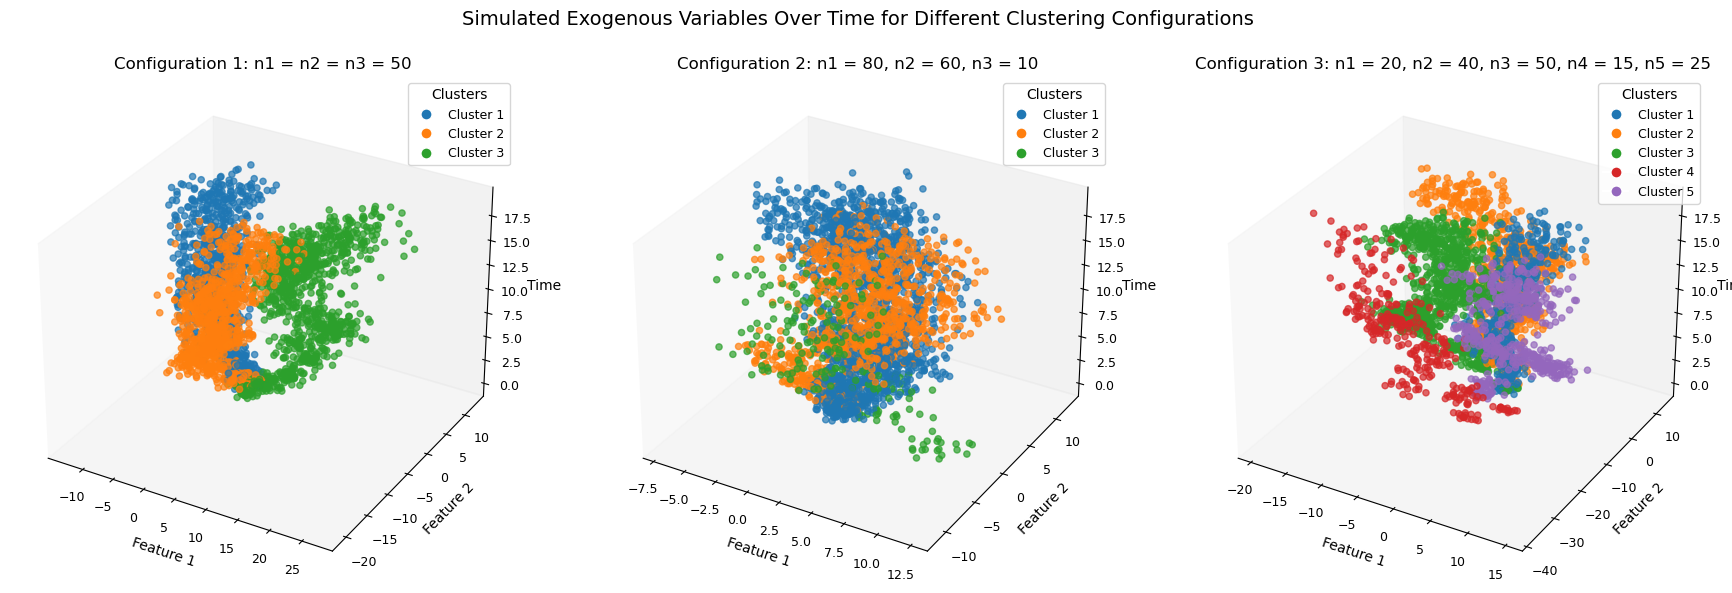

In [4]:
n = 150
T = 20

n_per_cluster = [50, 50, 50]
n_features = 2
n_clusters = 3
p = 0.4
q = 0.6
df1 = generate_data(n, T, n_clusters, n_per_cluster, n_features, p, q)
# Remettre les données sous un format dataframe avec en colonnes feature_1, feature_2, class et time
df1_frame, cluster_static_1 = dataframe_for_plot(df1, n_per_cluster)


n_per_cluster = [80, 60, 10]
df2 = generate_data(n, T, n_clusters, n_per_cluster, n_features, p, q)
df2_frame, cluster_static_2 = dataframe_for_plot(df2, n_per_cluster)


n = 150
n_clusters = 5
n_per_cluster = [20, 40, 50, 15, 25]
df3 = generate_data(n, T, n_clusters, n_per_cluster, n_features, p, q)
df3_frame, cluster_static_3 = dataframe_for_plot(df3, n_per_cluster)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import numpy as np

fig = plt.figure(figsize=(18, 6))
titles = [
    "Configuration 1: n1 = n2 = n3 = 50",
    "Configuration 2: n1 = 80, n2 = 60, n3 = 10",
    "Configuration 3: n1 = 20, n2 = 40, n3 = 50, n4 = 15, n5 = 25"
]
dfs = [df1_frame, df2_frame, df3_frame]
colormap = plt.cm.get_cmap('tab10')

for i, df in enumerate(dfs):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    
    # Obtenir les classes uniques triées
    classes = sorted(df["class"].unique())
    
    # Créer un mapping entre classe et couleur
    color_map = {cls: colormap(cls % 10) for cls in classes}

    # Appliquer les couleurs selon la classe
    colors = df["class"].map(color_map)

    # Scatter
    scatter = ax.scatter(df["feature_1"], df["feature_2"], df["time"],
                         c=colors, alpha=0.7)

    ax.set_xlabel("Feature 1", fontsize=10)
    ax.set_ylabel("Feature 2", fontsize=10)
    ax.set_zlabel("Time", fontsize=10)
    ax.set_title(titles[i], fontsize=12)
    ax.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=9)
    
    # Légende personnalisée avec les bonnes couleurs
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=f'Cluster {cls + 1}',
               markerfacecolor=color_map[cls], markersize=8)
        for cls in classes
    ]
    ax.legend(handles=legend_elements, title="Clusters", loc='upper right', fontsize=9, title_fontsize=10)

plt.suptitle("Simulated Exogenous Variables Over Time for Different Clustering Configurations", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Représentation des données
#plot_data([df1, cluster_static_1], title="3D Scatter Plot of Features and Time")
#plot_data([df2, cluster_static_2], title="3D Scatter Plot of Features and Time")
#plot_data([df3, cluster_static_3], title="3D Scatter Plot of Features and Time")

## I-) Test de différentes configurations des données simulées
Dans toutes les configurations on considère pour l'espace de décès les paramètres de simulations suivantes: 
- peak_position = [82, 78, 80]   
- scale = [10, 13, 15]
- max_observation = [2400, 4800, 3500]
- n_ages = 101

En ce qui concerne l'espace de décès, on considère:
- $p\in\{0.1, 0.4\}$
- $q\in\{0.9,0.6\}$

avec $p+q=1$

In [5]:
# Paramètres
n_ages = 101  # Les âges considéres (de 0 à 100)
peak_position = [82, 78, 80] # Position approximative du maximum
scale = [10, 13, 15]
max_observation = [2400, 4800, 3500] # Valeur maximale de l'observation

### a) Configuration 1: 
- ***Death_space*** $I_1 = I_2 = I_3 = 50$
- ***Covariate_space*** $I_1 = I_2 = I_3 = 50$

In [ ]:
I = 150
T = 20

# Génération des données de décès
n_clusters = 3
n_per_cluster = [60, 80, 10]
esp_observ1 = generate_death(peak_position, scale, max_observation, n_clusters, n_per_cluster, T, n_ages)

# Génération des données exogènes
n_covariates = 3
p = 0.4
q = 0.6
df1 = generate_data(I, T, n_clusters, n_per_cluster, n_covariates, p, q)

# Normalisation des données exogènes
df1_scaled = np.zeros_like(df1)
sc2 =MinMaxScaler()
df1_scaled = sc2.fit_transform(df1.reshape(I * T, n_covariates)).reshape(n, T, n_covariates)

# Combinaison des données
X = [esp_observ1, df1_scaled]

loss_list = []
best_params_list = []

n_classes = 3
clus = np.zeros((n_classes, T, n_covariates))
w = np.zeros((I, n_classes, T, n_covariates))
similarity_matrix = np.zeros((I, I))
lambda___ = 0
m__ = 0
lambda_ =[0.4, 0.6, 0.8, 1]
m = [1.2, 1.5, 2]

n_clusters = np.arange(2,8)
n_init = 10
X = [esp_observ1, df1_scaled]
from sklearn.model_selection import ParameterGrid

param_grid = {
    'lambda_': [0.4, 0.6, 0.8, 1],
    'm': [1.1, 1.5, 2]
}
grid = ParameterGrid(param_grid)
for n_clus in [3]:
    loss_params = float("inf")
    best_params_k = {}
    for params in grid:
        loss_algo = float("inf")
        print(f"Testing parameters: {params}")
        algo_st_kmeans = vectorized_st_kmeans_(n_clusters=n_clus, m=params["m"], lambda_=params["lambda_"], n_init=n_init, max_iter=100)
        _, _, _, loss_algo = algo_st_kmeans.fit(X)
        if  loss_algo < loss_params:
            loss_params = loss_algo
            best_params_k = params
    loss_list.append(loss_params)
    best_params_list.append(best_params_k)


Testing parameters: {'lambda_': 0.4, 'm': 1.1}
Initialization 1
Iteration 0, Loss: 4.687428029693763
Iteration 1, Loss: 4.259025150651057
Iteration 2, Loss: 4.161414510003366
Iteration 3, Loss: 4.129671217872238
Iteration 4, Loss: 4.096272033423958
Iteration 5, Loss: 4.092424975081293
Iteration 6, Loss: 4.08586317063977
Iteration 7, Loss: 4.065955691145836
Iteration 8, Loss: 4.063533820537175
Iteration 9, Loss: 4.062658640862321
Iteration 10, Loss: 4.062285113828257
Iteration 11, Loss: 4.061983433489496
Iteration 12, Loss: 4.061770088190617
Iteration 13, Loss: 4.061624583008272
Iteration 14, Loss: 4.061515767224668
Iteration 15, Loss: 4.061424416567073
Iteration 16, Loss: 4.061342162801757
Iteration 17, Loss: 4.061273268493215
Iteration 18, Loss: 4.061220317803359
Iteration 19, Loss: 4.061179296339527
Iteration 20, Loss: 4.061144401627395
Iteration 21, Loss: 4.061110408964419
Iteration 22, Loss: 4.061071412884146
Iteration 23, Loss: 4.0610182333761635
Iteration 24, Loss: 4.060936442305

In [ ]:
Contient les fonctions qui servent à déployer l'algorithme de FCMeans Spatio-Temporel adapté aux données de mortalité.
Init docstring: Initialise l'objet vectorized_st_kmeans_.
File: ~/work_vs_code/multipopulation/GNN/FCM_code/vectorized_STFCM.py
Type: type